In [1]:
import ROOT
from scipy import interpolate as interpolate
from scipy.stats import norm
import numpy as np
from utils import NonUniformStat, append_to_dict
import json
from matplotlib import pyplot as plt

In [2]:
BIAS = {}

with open("bias_dictionary.json", "r", encoding="utf-8") as f:
    BIAS = json.load(f)

tot_event, Dmu, Dsigma, nB_value = 0,0,0,0
#distribution = [169, 162, 188, 133, 121, 130, 162, 137, 195, 171, 154]

# load configuration file and read the configurations
with open("config.txt", 'r') as file:
    for line in file:
        line = line.strip()
        line = line.replace(" ","")
        if not ("#" in line):
            print(line)
        if not line:
            continue
        if 'Ntot' in line:
            key, value = line.split('=')
            tot_event = int(value)
        if 'nB_val' in line:
            key, value = line.split('=')
            nB_val = int(value)
        if 'Dmu' in line:
            key, value = line.split('=')
            Dmu = float(value)
        if 'Dsigma' in line:
            key, value = line.split('=')
            Dsigma = float(value)
        if 'real_gravity' in line:
            key, value = line.split('=')
            real_gravity = float(value)
        if 'Ntoys' in line:
            key, value = line.split('=')
            Ntoys = int(value)



Dmu=+0.02
Dsigma=0.08
K=0.85
real_gravity=-10
Ntot=1100
nB_val=7
Ntoys=1000
pfraction=0.5


In [3]:
Dmu    = Dmu
Dsigma = Dsigma
L      = 4
print(Dmu)

0.02


In [4]:
# Parameters
L = 6
Dsigma = 0.08


In [5]:
def sample_steep_region(n=200, k=1, a=1, g = -10):
    """
    Campiona n punti nella regione ripida di tanh(kx).
    a definisce quanto 'larga' è la regione ripida (in unità di 1/k).
    """
    x_min = -a / k + g/10
    x_max = +a / k + g/10
    xs = np.linspace(x_min, x_max, n) * 10
    return xs, x_min, x_max

In [6]:
BIAS = {}
#biasList = np.linspace( (real_gravity/10 - L/2)*10, (real_gravity/10 + L/2)*10, 7)

# a = 1.84 correspond to +0.95 for up and -0.95 for down
biasList, xmin, xmax = sample_steep_region(7, L, a = 1.84, g = real_gravity)
print(f"Interval region: [{xmin:.2f},{xmax:.2f}]")
print(f"bias list is {biasList}")

for bias in biasList:
    BIAS.update({f"{(bias/10):.1f}g" : int(bias)})

print(BIAS)

weights = {} # define the dictionary containing the statistics
for key, value in BIAS.items():
    weights.update( {key: int(tot_event/len(BIAS.values())) })

Interval region: [-1.31,-0.69]
bias list is [-13.06666667 -12.04444444 -11.02222222 -10.          -8.97777778
  -7.95555556  -6.93333333]
{'-1.3g': -13, '-1.2g': -12, '-1.1g': -11, '-1.0g': -10, '-0.9g': -8, '-0.8g': -7, '-0.7g': -6}


# Spline approximated with LINEAR SLOPE

In [7]:
# def scurve_model(x, L, g):
#     result = 0
#     if((-L/2 + g) < x and x < ( L/2 + g)):
#         result = 2/L * (x - g)
#     elif((-L/2 +g) >= x):
#         result = -.99
#     elif(x >= ( L/2 + g )):
#         result = +.99
#     return result

def scurve_model(x, L, g):
    return np.tanh(L * (x - g))

print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at -1.5 : %.1f" % scurve_model(-1.5,2,-1))
print("linear scurve evaluated at -1 : %.1f" % scurve_model(-1,2,-1))
print("linear scurve evaluated at -.5 : %.1f" % scurve_model(-.5,2,-1))
print("linear scurve evaluated at -2 : %.1f" % scurve_model(-2,2,-1))
print("linear scurve evaluated at 0 : %.1f"  % scurve_model(0,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(1,2,-1))
print("linear scurve evaluated at 1 : %.1f"  % scurve_model(10,2,-1))

linear scurve evaluated at -2 : -1.0
linear scurve evaluated at -1.5 : -0.8
linear scurve evaluated at -1 : 0.0
linear scurve evaluated at -.5 : 0.8
linear scurve evaluated at -2 : -1.0
linear scurve evaluated at 0 : 1.0
linear scurve evaluated at 1 : 1.0
linear scurve evaluated at 1 : 1.0


In [8]:
import csv

# ===  generate the True Asymemtry from Simulation
ASYMMETRY_TRUE = {}
for key, value in BIAS.items():
    ASYMMETRY_TRUE.update({key : float(scurve_model(value/10, L, real_gravity/10))})
    
print(ASYMMETRY_TRUE)

# Create simulation file
rows = []
for bias in np.linspace(-11, 9, 200):
    rows.append([bias, scurve_model(bias, L, real_gravity/10)])  # ogni riga = [bias, valore]
    print(bias, scurve_model(bias, L, 1) )

# save simulation file
with open("simulation.csv", "w", newline="") as f:
    writer = csv.writer(f)
    #writer.writerow(["bias", "scurve"])   # intestazioni opzionali
    writer.writerows(rows)

{'-1.3g': -0.9468060128462683, '-1.2g': -0.8336546070121552, '-1.1g': -0.5370495669980356, '-1.0g': 0.0, '-0.9g': 0.8336546070121552, '-0.8g': 0.9468060128462683, '-0.7g': 0.9836748576936802}
-11.0 -1.0
-10.899497487437186 -1.0
-10.798994974874372 -1.0
-10.698492462311558 -1.0
-10.597989949748744 -1.0
-10.49748743718593 -1.0
-10.396984924623116 -1.0
-10.296482412060302 -1.0
-10.195979899497488 -1.0
-10.095477386934673 -1.0
-9.99497487437186 -1.0
-9.894472361809045 -1.0
-9.793969849246231 -1.0
-9.693467336683417 -1.0
-9.592964824120603 -1.0
-9.492462311557789 -1.0
-9.391959798994975 -1.0
-9.291457286432161 -1.0
-9.190954773869347 -1.0
-9.090452261306533 -1.0
-8.989949748743719 -1.0
-8.889447236180905 -1.0
-8.78894472361809 -1.0
-8.688442211055277 -1.0
-8.587939698492463 -1.0
-8.487437185929648 -1.0
-8.386934673366834 -1.0
-8.28643216080402 -1.0
-8.185929648241206 -1.0
-8.085427135678392 -1.0
-7.984924623115578 -1.0
-7.884422110552764 -1.0
-7.78391959798995 -1.0
-7.683417085427136 -1.0
-

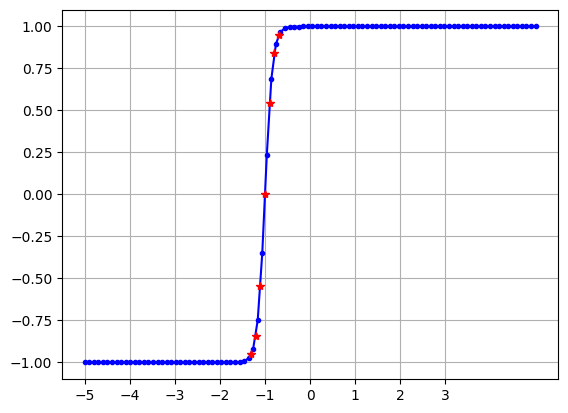

In [9]:
plt.figure(1)
xpoints = np.linspace(-5,5,100)
ypoints = [scurve_model(item, L, real_gravity/10) for item in xpoints]
plt.errorbar(xpoints, ypoints, marker = '.', color = 'blue')
plt.xticks([-5,-4,-3,-2,-1,0,1,2,3])
ypoints = [scurve_model(item/10, L, real_gravity/10) for item in biasList]
xpoints = np.array(biasList)/10
plt.errorbar(xpoints, ypoints, linestyle = "" ,marker = "*", color = "red")
plt.grid()
plt.savefig(f"scurve_L_{L}.png")

# Open The Workspace with the PDFs

In [10]:
f = ROOT.TFile("analysis_output/workspace.root")
w = f.Get("w")
w.Print("v")

w['c_pbarDn_1'].setVal(1.0); w['c_pbarDn_1'].setConstant(True)
w['c_pbarUp_1'].setVal(1.0); w['c_pbarUp_1'].setConstant(True)


RooWorkspace(w) w contents

variables
---------
(Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype)

p.d.f.s
-------
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooHistPdf::pdf_cosm[ pdfObs=(Z) ] = 1.8628
RooAddPdf::pdf_pbarDn[ c_pbarDn_1 * hpdf_pbarDn_1 + [%] * hpdf_pbarDn_2 ] = 0.0121951/1
RooAddPdf::pdf_pbarUp[ c_pbarUp_1 * hpdf_pbarUp_1 + [%] * hpdf_pbarUp_2 ] = 0.844512/1

datasets
--------
RooDataHist::rdhbin_pbarUp1(Z)
RooDataHist::rdhbin_pbarUp2(Z)
RooDataHist::rdhbin_pbarDn1(Z)
RooDataHist::rdhbin_pbarDn2(Z)

embedded datasets (in pdfs and functions)
-----------------------------------------
RooDataHist::rhcosm(Z)



In [11]:
Z = w['Z']
zframe = Z.frame(Title = "Z Distributions, Templates")
w['pdf_pbarUp'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kRed))
w['pdf_pbarDn'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kBlue))
w['pdf_cosm'].plotOn(zframe, ROOT.RooFit.LineColor(ROOT.kGreen))

c = ROOT.TCanvas("pdfs_templates", "pdfs_templates", 600, 600)
ROOT.gPad.SetLeftMargin(0.15)
zframe.GetYaxis().SetTitleOffset(1.4)
zframe.Draw()
c.Draw()

# Create the RooDataSet

In [12]:
BiasCategory = ROOT.RooCategory("secondCategory", "a second category", BIAS)
BiasCategory.Print("v")

#dataset = ROOT.RooDataSet("data","data", ROOT.RooArgSet(Z,BiasCategory))

--- RooAbsArg ---
  Value State: clean
  Shape State: clean
  Attributes: 
  Address: 0x635ee804c8b0
  Clients: 
  Servers: 
  Proxies: 
--- RooAbsCategory ---
  Value = -13 "-1.3g)
  Possible states:
    -0.7g	-6
    -0.8g	-7
    -0.9g	-8
    -1.0g	-10
    -1.1g	-11
    -1.2g	-12
    -1.3g	-13


In [13]:
simModelBase = ROOT.RooSimultaneous("model_base_simultaneous", "model for bias", BiasCategory)

# 2. Crea un mapping da categoria (es. "-1.0g") a PDF personalizzato

pdf_per_categoria = {} # senno muoiono

for category, weight in weights.items():
    print(f"Setting up PDF for category: {category}")
    
    # Calcolo degli eventi Up/Down
    Nup   = 0.5 * weight * (1 - ASYMMETRY_TRUE[category])
    Ndown = 0.5 * weight * (1 + ASYMMETRY_TRUE[category])
    
    # Costanti per RooAddPdf
    nup_const = ROOT.RooFit.RooConst(Nup)
    ndwn_const = ROOT.RooFit.RooConst(Ndown)
    
    # PDF composita per questa categoria
    model_i = ROOT.RooAddPdf(f"pdf_{category}", f"pdf_{category}",
                             ROOT.RooArgList(w['pdf_pbarUp'], w['pdf_pbarDn']),
                             ROOT.RooArgList(nup_const, ndwn_const))
    pdf_per_categoria[category] = model_i
    
    # Aggiungila alla simultanea
    simModelBase.addPdf(model_i, category)

Setting up PDF for category: -1.3g
Setting up PDF for category: -1.2g
Setting up PDF for category: -1.1g
Setting up PDF for category: -1.0g
Setting up PDF for category: -0.9g
Setting up PDF for category: -0.8g
Setting up PDF for category: -0.7g


In [14]:
# Generazione separata per ciascuna categoria
dataset = simModelBase.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
dataset.Print("v")

DataStore hmaster (hmaster)
  Contains 14 entries
  Observables: 
    1)               Z = -450  L(-875.35 - -219.35) B(2)  "Z"
    2)  secondCategory = -1.3g(idx = -13)
  "a second category"


In [15]:
ttable = dataset.table(BiasCategory)
ttable.Print("v")


  Table secondCategory : hmaster
  +-------+-----+
  | -1.3g | 146 |
  | -1.2g | 177 |
  | -1.1g | 138 |
  | -1.0g | 145 |
  | -0.9g | 166 |
  | -0.8g | 170 |
  | -0.7g | 190 |
  +-------+-----+



In [16]:
c1 = ROOT.TCanvas("data_plot", "data_plot", 800, 800)

zframe1 = Z.frame( ROOT.RooFit.Bins(18), Title = "Plot of Z data")
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -30'), ROOT.RooFit.MarkerColor(ROOT.kBlue),  ROOT.RooFit.Name("cat_-30"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == -20'), ROOT.RooFit.MarkerColor(ROOT.kRed),   ROOT.RooFit.Name("cat_-20"))
dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == 30'), ROOT.RooFit.MarkerColor(ROOT.kGreen),  ROOT.RooFit.Name("cat_+30"))
#dataset.plotOn(zframe1, ROOT.RooFit.Cut('secondCategory == +20'), ROOT.RooFit.MarkerColor(6),   ROOT.RooFit.Name("cat_-20"))
#w['model_base'].plotOn(zframe1)

#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kBlue))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "-2.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kRed))
#simModelBase.plotOn(zframe1, ROOT.RooFit.Slice(BiasCategory, "+3.0g") , ROOT.RooFit.ProjWData(ROOT.RooArgSet(BiasCategory), dataset) , ROOT.RooFit.LineColor(ROOT.kGreen))

zframe1.Draw()

# Crea la legenda
legend = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)  # x1,y1,x2,y2 in NDC (posizione)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.AddEntry(zframe1.findObject("cat_-30"), "-3.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_-20"), "-2.0g", "lep")
legend.AddEntry(zframe1.findObject("cat_+30"), "+3.0g", "lep")
legend.Draw()

c1.Draw()

[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1132 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1132 total events
[#1] INFO:Plotting -- RooTreeData::plotOn: plotting 0 events out of 1132 total events


# Construction of the model for the Simulation

In [17]:
w.Import(BiasCategory) # <== Import the category inside the workspace

w.factory("S[100,50, 10000]")
w.factory("E[0.0, -1.5, 1.5]")
w.factory(f"D[{Dmu}, -0.8, 0.8]")

w.factory("SUM::model_base( Nup[30,10000] * pdf_pbarUp, Ndwn[30,1000] * pdf_pbarDn, nB[1, 200] * pdf_cosm)") # <<< Add pdf_cosm in the future
# A = (Ndwn - Nup)/(Ndwn + Nup)
w.factory(f"EDIT::model_MAGB(model_base, Nup=expr('0.5*S*(1-E)', S, E), Ndwn = expr('0.5*S*(1+E)', S, E))")

w.factory(f"Gaussian::Dconstr(D,{Dmu},{Dsigma})") # constrain on D, efficiency

w.factory("SIMCLONE::model_fit( model_MAGB, $SplitParam({S,E}, secondCategory ))") # Clone the Models

w.Print()

[#1] INFO:ObjectHandling -- RooWorkspace::import(w) importing RooCategory::secondCategory

RooWorkspace(w) w contents

variables
---------
(D,E,E_-0.7g,E_-0.8g,E_-0.9g,E_-1.0g,E_-1.1g,E_-1.2g,E_-1.3g,Ndwn,Nup,S,S_-0.7g,S_-0.8g,S_-0.9g,S_-1.0g,S_-1.1g,S_-1.2g,S_-1.3g,Z,biaskey,c_pbarDn_1,c_pbarDn_2,c_pbarUp_1,c_pbarUp_2,evtype,nB,secondCategory)

p.d.f.s
-------
RooGaussian::Dconstr[ x=D mean=0.02 sigma=0.08 ] = 1
RooHistPdf::hpdf_pbarDn_1[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarDn_2[ pdfObs=(Z) ] = 0.0121951
RooHistPdf::hpdf_pbarUp_1[ pdfObs=(Z) ] = 0.844512
RooHistPdf::hpdf_pbarUp_2[ pdfObs=(Z) ] = 0.844512
RooAddPdf::model_MAGB[ model_MAGB_2 * pdf_pbarUp + model_MAGB_3 * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-0.7g[ model_MAGB_2_-0.7g * pdf_pbarUp + model_MAGB_3_-0.7g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAGB_-0.8g[ model_MAGB_2_-0.8g * pdf_pbarUp + model_MAGB_3_-0.8g * pdf_pbarDn + nB * pdf_cosm ] = 1.14737/1
RooAddPdf::model_MAG

In [18]:
g = ROOT.TGraph("simulation.csv","%lg,%lg")
# create RooRealVar
w.factory('c[0,-30,30]')
#create RooRealVar
w.factory('scale[0.1]')
#w['scale'].setConstant(True)
w["nB"].setVal(nB_val)

# === Definisci la curva S come TF1 + RooTFnBinding ===
def Scurve_fn(x, p):
    # 10 is an offset of the simulation
    offset = -10
    bias = x[0]
    c = p[0]
    scale = p[1]
    D = p[2]
    return (g.Eval((x[0] - c + offset) * scale) - D)/(1 - g.Eval((x[0] - c + offset) * scale)*D)

# === Print values of the Scurve for a collection of biases ===
print("-"*8)
for key,value in BIAS.items():
    val = Scurve_fn([value], [w["c"].getVal(), w['scale'].getVal(), w['D'].getVal()])
    print(f"{key}| {value} | {w['c'].getVal()} | {val}")
print("-"*8)

# === create the RooFit model from the Scurve ===
Scurve_TF1 = ROOT.TF1("Scurve",Scurve_fn, -50, 50, 3) # not possible to put in workspace

cust = ROOT.RooCustomizer(w.pdf('model_fit'), "scurve");

vcat={}
nasy={}
for bkt, bias_val in BIAS.items():
    v = ROOT.RooRealVar(f"vat_{bkt}", "", bias_val)
    # Creo una funzione parametrica RooTFnBinding che connette il TF1 alla variabile 'v'
    # Il TF1 ha 3 parametri: c, scale, D — sono usati qui come [c, scale, D]
    asy = ROOT.RooTFnBinding(f"nasy_{bkt}", "", Scurve_TF1, v, [w['c'], w['scale'], w['D']])
    # Salvo queste entità nei dizionari
    vcat[bkt] = v
    nasy[bkt] = asy

    # Ottengo la variabile originale 'E_{bkt}' nel modello
    A = w.var(f'E_{bkt}')

    # Sostituisco E_{bkt} con la funzione curva S corrispondente
    cust.replaceArg(A, asy)

scurve_all = cust.build(True)

scurvemap = {}
for bkt, bias_val in BIAS.items():
    scurvemap.update({bkt : scurve_all.getPdf(bkt) })
    S = w.var(f'S_{bkt}')

    val = ttable.get(bkt)
    err = np.sqrt(val)
    
    #S.setMin(val-10*err)
    #S.setMax(val+10*err)
    S.setVal(val)
    print(f"setting  {val}  [{val - 10*err}  {val + 10*err}]")
    #S.setError(err)

scurve_fit = ROOT.RooSimultaneous("scurve_fit","scurve_fit", scurvemap, BiasCategory)

--------
-1.3g| -13 | 0.0 | -0.99999962100592
-1.2g| -12 | 0.0 | -0.9999987404639533
-1.1g| -11 | 0.0 | -0.9999958142134916
-1.0g| -10 | 0.0 | -0.9999860898947488
-0.9g| -8 | 0.0 | -0.9998464076746773
-0.8g| -7 | 0.0 | -0.9994897396117781
-0.7g| -6 | 0.0 | -0.9983057740470133
--------


setting  146.0  [25.169540264054277  266.83045973594574]
setting  177.0  [43.95865304349928  310.0413469565007]
setting  138.0  [20.526598755292696  255.4734012447073]
setting  145.0  [24.584054212077035  265.41594578792296]
setting  166.0  [37.15901273274875  294.84098726725125]
setting  170.0  [39.615951895947006  300.384048104053]
setting  190.0  [52.15951247909777  327.84048752090223]


[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.7g will be replaced by nasy_-0.7g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.8g will be replaced by nasy_-0.8g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-0.9g will be replaced by nasy_-0.9g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.0g will be replaced by nasy_-1.0g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.1g will be replaced by nasy_-1.1g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.2g will be replaced by nasy_-1.2g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit): tree node E_-1.3g will be replaced by nasy_-1.3g
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit) Branch node RooSimultaneous::model_fit cloned: depends on a replaced parameter
[#1] INFO:ObjectHandling -- RooCustomizer::build(model_fit) Branch node RooAddPdf::model_MA

In [19]:
w['D'].setConstant(True)

w['c'].setError(20)
result = scurve_fit.fitTo(dataset,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.Minos(w['c']))

c     = w.var('c')
scale = w.var('scale')
D = w.var('D')

# === 8. Risultati
print("\n=== RISULTATI DEL FIT ===")
print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
print(f"fit status: {result.status()}")


=== RISULTATI DEL FIT ===
c     = -0.9953 ± 0.0096; [-0.00958137555608473,+0.009551993004046341]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0


[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using CPU computation library compiled with -mavx2
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
Minuit2Minimizer: Minimize with max-calls 4500 convergence for edm < 1 strategy 2
Minuit2Minimizer : Valid minimum - status = 0
FVAL  = 4484.0643220498032
Edm   = 0.000190927603472891257
Nfcn  = 699
S_-0.7g	  = 189.074	 +/-  13.792	(limited)
S_-0.8g	  = 168.996	 +/-  13.0419	(limited)
S_-0.9g	  = 165.162	 +/-  12.8871	(limited)
S_-1.0g	  = 144.087	 +/-  12.0508	(limited)
S_-1.1g	  = 136.911	 +/-  11.7523	(limited)
S_-1.2g	  = 176.123	 +/-  13.306	(limited)
S_-1.3g

Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =       6287.753938 Edm =        1439.07775 NCalls =     39
Warning in <Minuit2>: MnPosDef Matrix forced pos-def by adding to diagonal 1.00531
Info in <Minuit2>: MnSeedGenerator run Hesse - Initial seeding state: 
  Minimum value : 6287.753938
  Edm           : 146529.1657
  Internal parameters:	[     -1.332999413      -1.35071362     -1.354427378     -1.375058943     -1.382430531     -1.344358725     -1.374028124                0     -1.221747644]	
  Internal gradient  :	[      719.8431528      691.7297572      675.7302615      299.9947305      199.5784145      69.27503153      57.86837737      201.7433463     -1823.915215]	
  Internal covariance matrix:
[[    0.032419334    0.016184929    0.011779673   0.0035922405   0.0023937071   0.0010425831  0.00098033811    -0.27003546   -0.080902531]
 [    0.016184929   0.0083845197   0.0059282606   0.001808

In [20]:
scurve_fit.getParameters(dataset).Print('v')

  1) 0x635ee8894130 RooRealVar::          D = 0.02 C  L(-0.8 - 0.8)  "D"
  2) 0x635ee8c04dc0 RooRealVar::    S_-0.7g = 189.074 +/- 13.7883  L(50 - 10000)  "S (-0.7g)"
  3) 0x635ee8b9ecc0 RooRealVar::    S_-0.8g = 168.996 +/- 13.0381  L(50 - 10000)  "S (-0.8g)"
  4) 0x635ee8ba8880 RooRealVar::    S_-0.9g = 165.162 +/- 12.8844  L(50 - 10000)  "S (-0.9g)"
  5) 0x635ee8bb2440 RooRealVar::    S_-1.0g = 144.087 +/- 12.0467  L(50 - 10000)  "S (-1.0g)"
  6) 0x635ee8c7c270 RooRealVar::    S_-1.1g = 136.911 +/- 11.7473  L(50 - 10000)  "S (-1.1g)"
  7) 0x635ee8c85c50 RooRealVar::    S_-1.2g = 176.123 +/- 13.3032  L(50 - 10000)  "S (-1.2g)"
  8) 0x635ee8c8f810 RooRealVar::    S_-1.3g = 144.743 +/- 12.0775  L(50 - 10000)  "S (-1.3g)"
  9) 0x635ee8bbf600 RooRealVar::          c = -9.95267 +/- (-0.0958138,0.0955199)  L(-30 - 30)  "c"
 10) 0x635ee4ed8cf0 RooRealVar:: c_pbarDn_1 = 1 C  L(0.71251 - 1)  "c_pbarDn_1"
 11) 0x635ee100a2e0 RooRealVar:: c_pbarUp_1 = 1 C  L(-0.0202152 - 1)  "c_pbarUp_1"
 12) 0

# SIMULATION, nominal case (2023 analysis), D set as constant

In [21]:
Ngravity = []
dNgravity = []

D.setConstant(True)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)

    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())
        
    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 #ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0006 ± 0.0089; [-0.008958943950637439,+0.008873256140824478]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9994 ± 0.0097; [-0.009685692692333638,+0.009693135401176495]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 se


=== RISULTATI DEL FIT ===
c     = -1.0138 ± 0.0094; [-0.009546327846771254,+0.009202401479541752]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9882 ± 0.0101; [-0.01005757456685518,+0.010268107614458072]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9980 ± 0.0102; [-0.010204153005927336,+0.010284499120435747]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val


=== RISULTATI DEL FIT ===
c     = -1.0081 ± 0.0101; [-0.010056289400156225,+0.01008595776358686]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0043 ± 0.0103; [-0.010380468526923693,+0.010232479086973105]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0



=== RISULTATI DEL FIT ===
c     = -0.9999 ± 0.0099; [-0.009896150630079426,+0.009899656639809259]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0027 ± 0.0102; [-0.010202229062856265,+0.010130214840169955]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0029 ± 0.0099; [-0.009867115236086878,+0.009870346177822448]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -0.9860 ± 0.0099; [-0.009892237571733237,+0.00988694400534313]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9997 ± 0.0092; [-0.009286599010543344,+0.009203943064834486]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9967 ± 0.0091; [-0.009081033440732182,+0.009109500767783186]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val

...


=== RISULTATI DEL FIT ===
c     = -0.9921 ± 0.0105; [-0.01048356219984548,+0.010575915683105015]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9816 ± 0.0110; [-0.010967639391169045,+0.011098194563832006]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9955 ± 0.0094; [-0.009329348162045897,+0.009544983473387026]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val


=== RISULTATI DEL FIT ===
c     = -0.9900 ± 0.0090; [-0.00894792067595825,+0.008972808230610859]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9954 ± 0.0092; [-0.009209208416768476,+0.00913812039324714]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9958 ± 0.0096; [-0.009481150179783128,+0.009642388521817896]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set valu


=== RISULTATI DEL FIT ===
c     = -1.0068 ± 0.0095; [-0.009554832918887687,+0.009535297851343067]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0129 ± 0.0094; [-0.009403166617422262,+0.009433791073423563]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9996 ± 0.0092; [-0.009167631213653559,+0.009175606312109792]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -1.0091 ± 0.0099; [-0.009984236454062349,+0.009818753931823158]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9922 ± 0.0096; [-0.009492247653978264,+0.009718538261430744]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9923 ± 0.0097; [-0.009599265081692121,+0.009726223679605529]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -1.0094 ± 0.0098; [-0.00987218950982414,+0.009657931977105058]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9988 ± 0.0097; [-0.009654906155271682,+0.00972259699377881]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9901 ± 0.0112; [-0.010935246506848576,+0.011466548616365252]
scale = 0.1000 ± 0.0000
D     = 0.0200 ± 0.0000
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set valu

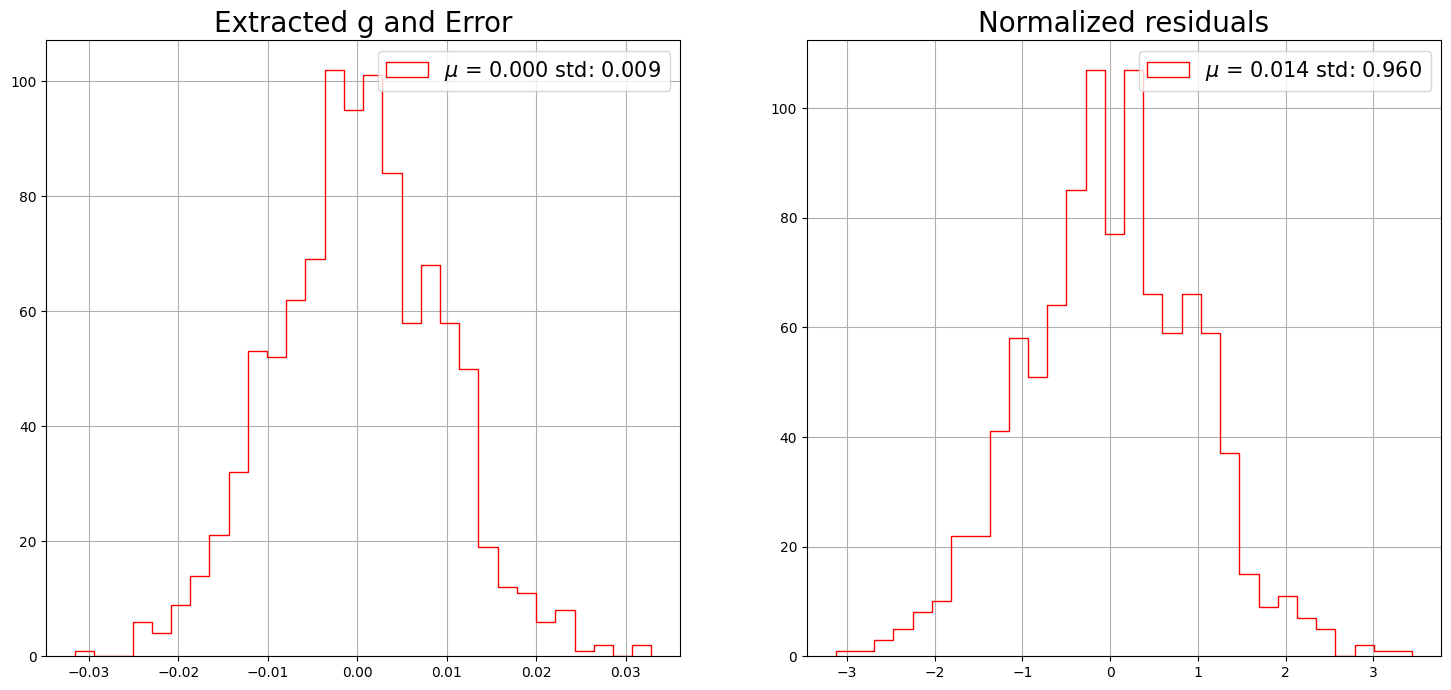

In [22]:
from matplotlib import pyplot as plt

#print(res_norm)
plt.figure(9, figsize = (18,8))
plt.subplot(1,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.subplot(1,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")
plt.savefig(f"residuals_L_{L}.png", bbox_inches = 'tight')

# Fit with D

In [23]:
Ngravity = []
dNgravity = []
ND = []
dND = []

D.setConstant(False)

for i in range(0, Ntoys):
    c.setVal(real_gravity) # reset the value for simulation
    w["nB"].setVal(nB_val)
    D.setVal(Dmu + np.random.normal(loc = 0, scale = Dsigma))  # D detector asymmetry, add a "manual smearing, because the simulation does not account for a generation of D"
    
    for bias, stat in weights.items(): # reset the stat parameters
        w[f"S_{bias}"].setVal(stat)
        print("tot_events:", stat, "set value:", w[f"S_{bias}"].getVal())

    
    pseudo_data = scurve_fit.generate(ROOT.RooArgSet(Z, BiasCategory), ROOT.RooFit.Extended())
    c.setVal(-10)
    result = scurve_fit.fitTo(pseudo_data,
                 ROOT.RooFit.Minimizer("Minuit2","minimize"),
                 ROOT.RooFit.ExternalConstraints(w['Dconstr']),
                 ROOT.RooFit.Strategy(2),
                 ROOT.RooFit.Save(),
                 ROOT.RooFit.PrintLevel(-1),
                 #ROOT.RooFit.Verbose(False),   # disattiva log verboso
                 #ROOT.RooFit.Warnings(False),  # opzionale: disattiva warning
                 ROOT.RooFit.Minos(w['c']))
    # === 8. Risultati
    print("\n=== RISULTATI DEL FIT ===")
    print(f"c     = {c.getVal()*scale.getVal():.4f} ± {c.getError()*scale.getVal():.4f}; [{c.getErrorLo()*scale.getVal()},+{c.getErrorHi()*scale.getVal()}]")
    print(f"scale = {scale.getVal():.4f} ± {scale.getError():.4f}")
    print(f"D     = {D.getVal():.4f} ± {D.getError():.4f}")
    print(f"fit status: {result.status()}")

    if result.status() < 1 and not np.isnan(c.getError()) and c.getError() > 0:
        Ngravity.append(c.getVal()*scale.getVal() - real_gravity*scale.getVal())
        dNgravity.append(c.getError()*scale.getVal())
        ND.append(D.getVal() - Dmu)
        dND.append(D.getError())

# === Normalized Residuals ===
res_norm = (np.array((Ngravity)))/np.array(dNgravity)
Dres_norm = (np.array((ND)))/np.array(dND)

tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0124 ± 0.0178; [-0.017763288046578722,+0.017660903377363465]
scale = 0.1000 ± 0.0000
D     = 0.0254 ± 0.0806
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0108 ± 0.0164; [-0.016739956765477695,+0.01587817363808368]
scale = 0.1000 ± 0.0000
D     = 0.0139 ± 0.0773
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set


=== RISULTATI DEL FIT ===
c     = -1.0077 ± 0.0182; [-0.018423676717389526,+0.017844472265945883]
scale = 0.1000 ± 0.0000
D     = 0.0287 ± 0.0842
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0142 ± 0.0177; [-0.017444533270016684,+0.017713739988204465]
scale = 0.1000 ± 0.0000
D     = 0.0283 ± 0.0817
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9996 ± 0.0165; [-0.016522736256606097,+0.016312554987802107]
scale = 0.1000 ± 0.0000
D     = 0.0206 ± 0.0775
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va


=== RISULTATI DEL FIT ===
c     = -0.9597 ± 0.0154; [-0.016231762781437883,+0.01455083509425529]
scale = 0.1000 ± 0.0000
D     = 0.0213 ± 0.0769
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9743 ± 0.0176; [-0.01801139834056335,+0.01713567137291371]
scale = 0.1000 ± 0.0000
D     = 0.0150 ± 0.0821
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0031 ± 0.0177; [-0.017972829929888298,+0.01739543968588642]
scale = 0.1000 ± 0.0000
D     = 0.0216 ± 0.0832
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value:


=== RISULTATI DEL FIT ===
c     = -1.0216 ± 0.0164; [-0.01622286723953219,+0.016519465453842013]
scale = 0.1000 ± 0.0000
D     = 0.0166 ± 0.0777
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0316 ± 0.0168; [-0.01648175029393863,+0.017039968274942942]
scale = 0.1000 ± 0.0000
D     = 0.0214 ± 0.0771
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0122 ± 0.0152; [-0.015199397913173096,+0.01507481587674264]
scale = 0.1000 ± 0.0000
D     = 0.0097 ± 0.0732
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value


=== RISULTATI DEL FIT ===
c     = -1.0264 ± 0.0174; [-0.017064933234908534,+0.017550328498103885]
scale = 0.1000 ± 0.0000
D     = 0.0245 ± 0.0802
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9985 ± 0.0182; [-0.018453101264141687,+0.017836359697385857]
scale = 0.1000 ± 0.0000
D     = 0.0191 ± 0.0834
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9990 ± 0.0160; [-0.016120014955989796,+0.015809065623886807]
scale = 0.1000 ± 0.0000
D     = 0.0160 ± 0.0768
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set va

...


=== RISULTATI DEL FIT ===
c     = -0.9875 ± 0.0174; [-0.017473341222338883,+0.017231573790728046]
scale = 0.1000 ± 0.0000
D     = 0.0177 ± 0.0813
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0035 ± 0.0171; [-0.01723780672083609,+0.016869216931638054]
scale = 0.1000 ± 0.0000
D     = 0.0173 ± 0.0809
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9979 ± 0.0192; [-0.019342838063715954,+0.018834802415170833]
scale = 0.1000 ± 0.0000
D     = 0.0243 ± 0.0880
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val


=== RISULTATI DEL FIT ===
c     = -0.9659 ± 0.0160; [-0.016427861347105385,+0.0162843280482186]
scale = 0.1000 ± 0.0000
D     = 0.0322 ± 0.0783
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0110 ± 0.0166; [-0.01675751380604199,+0.016283799011707442]
scale = 0.1000 ± 0.0000
D     = 0.0165 ± 0.0783
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9830 ± 0.0152; [-0.015051285374371165,+0.015298003003425101]
scale = 0.1000 ± 0.0000
D     = 0.0315 ± 0.0742
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value


=== RISULTATI DEL FIT ===
c     = -1.0146 ± 0.0176; [-0.01758469523205666,+0.017530708956111304]
scale = 0.1000 ± 0.0000
D     = 0.0163 ± 0.0810
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9927 ± 0.0176; [-0.017645538509243323,+0.017432932053311763]
scale = 0.1000 ± 0.0000
D     = 0.0183 ± 0.0824
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -0.9981 ± 0.0154; [-0.015571037836520108,+0.015034293802175972]
scale = 0.1000 ± 0.0000
D     = 0.0154 ± 0.0759
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val


=== RISULTATI DEL FIT ===
c     = -0.9924 ± 0.0173; [-0.017487611075440456,+0.01686910335594958]
scale = 0.1000 ± 0.0000
D     = 0.0195 ± 0.0813
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0065 ± 0.0173; [-0.017278291666416836,+0.017074503340363145]
scale = 0.1000 ± 0.0000
D     = 0.0214 ± 0.0802
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0
tot_events: 157 set value: 157.0

=== RISULTATI DEL FIT ===
c     = -1.0089 ± 0.0168; [-0.016698582248508308,+0.016680149976790737]
scale = 0.1000 ± 0.0000
D     = 0.0161 ± 0.0785
fit status: 0
tot_events: 157 set value: 157.0
tot_events: 157 set val

[#1] INFO:Minimization -- p.d.f. provides expected number of events, including extended term in likelihood.
[#1] INFO:Minimization --  Including the following constraint terms in minimization: (Dconstr)
[#1] INFO:Minimization -- The global observables are not defined , normalize constraints with respect to the parameters (D,S_-0.7g,S_-0.8g,S_-0.9g,S_-1.0g,S_-1.1g,S_-1.2g,S_-1.3g,c,c_pbarDn_1,c_pbarUp_1,nB,scale,vat_-0.7g,vat_-0.8g,vat_-0.9g,vat_-1.0g,vat_-1.1g,vat_-1.2g,vat_-1.3g)
[#1] INFO:Fitting -- RooAbsPdf::fitTo(scurve_fit) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_scurve_fit_hmaster) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Minimization -- p.d.f. provides expected number of event

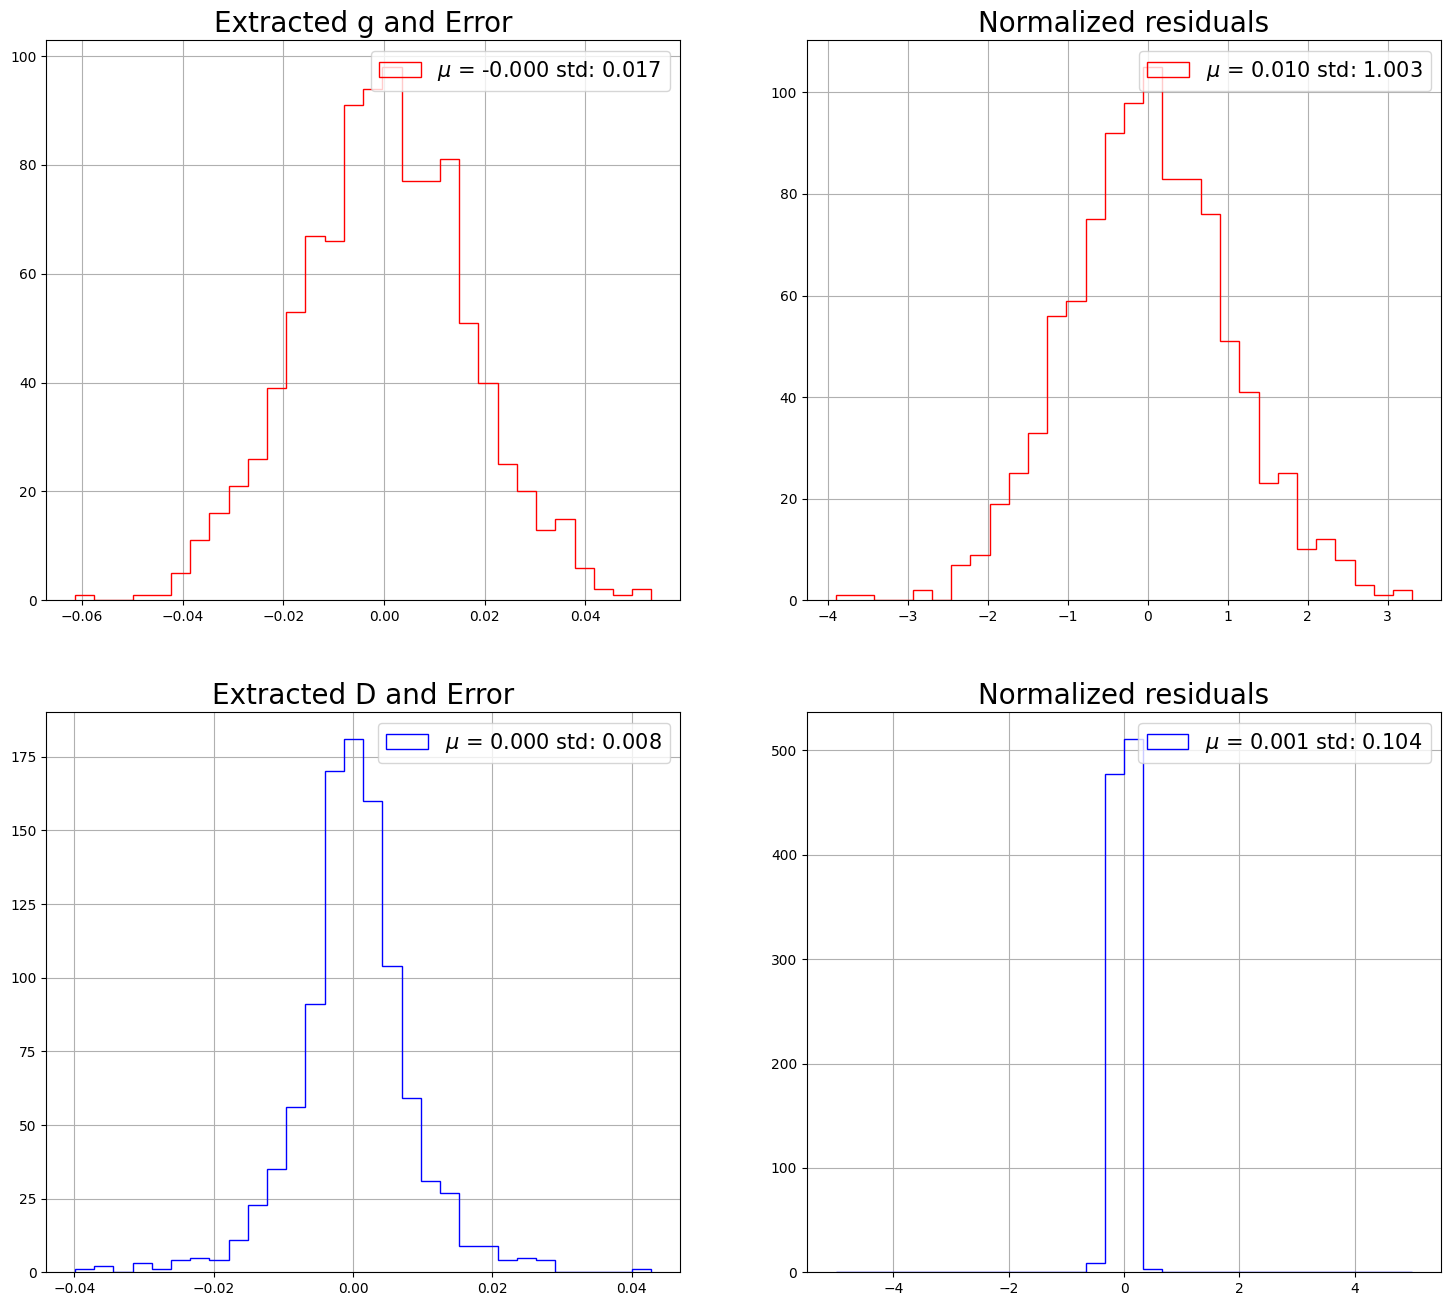

In [24]:
#print(res_norm)
plt.figure(10, figsize = (18,16))
plt.subplot(2,2,1)
plt.title("Extracted g and Error", fontsize = 20)
plt.grid()
plt.hist(Ngravity, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(Ngravity):.3f} std: {np.std(Ngravity):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,2)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(res_norm, bins = 30, histtype = 'step', color = 'red', linestyle = '-', label = f'$\mu$ = {np.mean(res_norm):.3f} std: {np.std(res_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

#plt.figure(11, figsize = (18,8))
plt.subplot(2,2,3)
plt.title("Extracted D and Error", fontsize = 20)
plt.grid()
plt.hist(ND, bins = 30, histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(ND):.3f} std: {np.std(ND):.3f}')
plt.legend(fontsize = 15,  loc = "upper right")
plt.subplot(2,2,4)
plt.title("Normalized residuals", fontsize = 20)
plt.grid()
plt.hist(Dres_norm, bins = 30, range = (-5, 5), histtype = 'step', color = 'blue', linestyle = '-', label = f'$\mu$ = {np.mean(Dres_norm):.3f} std: {np.std(Dres_norm):.3f}')
plt.legend(fontsize = 15, loc = "upper right")

plt.savefig(f"residuals_D_L_{L}.png", bbox_inches = 'tight')